In [ ]:
# Импортируем класс Path из модуля pathlib — он упрощает работу с файловыми путями
# (создание, проверка существования, навигация по директориям и т. д.)
from pathlib import Path

# Импортируем библиотеку pandas под псевдонимом pd — она нужна для работы с табличными данными
# (чтение CSV‑файлов, анализ, предобработка и т. п.)
import pandas as pd

# Импортируем модуль Image из библиотеки PIL (Pillow) — он позволяет загружать,
# обрабатывать и сохранять изображения в разных форматах
from PIL import Image

# Из библиотеки PyTorch импортируем базовые классы для создания датасета (Dataset)
# и загрузчика данных (DataLoader), которые нужны для эффективной подачи данных в модель
from torch.utils.data import Dataset, DataLoader

# Импортируем модуль transforms из библиотеки torchvision — он содержит
# готовые преобразования изображений (нормализация, аугментации и т. д.),
# которые удобно применять перед подачей в нейронную сеть
from torchvision import transforms

# Импортируем библиотеку timm (PyTorch Image Models) — она предоставляет
# доступ к сотням предобученных моделей компьютерного зрения (ResNet, EfficientNet и др.)
import timm

# Импортируем основную библиотеку PyTorch — она нужна для построения и обучения
# нейронных сетей: работы с тензорами, автодифференцирования, оптимизации и т. д.
import torch

# Импортируем модуль pyplot из библиотеки matplotlib под псевдонимом plt —
# он используется для визуализации данных: построения графиков, отображения изображений и т. п.
import matplotlib.pyplot as plt


import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


In [2]:
data_path = '../data/room_type/'
train_df_path = data_path+'train_df.csv'
train_dir = data_path + 'train_images/train_images'
train_df = pd.read_csv(train_df_path)
train_df.head()

,item_id,image,image_id_ext,result,label,ratio
0,1375153252730,http://labelimages.avito.ru/16028356846.jpg,16028356846,9,совмещенный санузел,1.000000
1,1375170002401,http://labelimages.avito.ru/16029739656.jpg,16029739656,1,кухня-гостиная,0.666667
2,1342634751186,http://labelimages.avito.ru/15209120394.jpg,15209120394,10,коридор / прихожая,1.000000
3,1351692753345,http://labelimages.avito.ru/15233743709.jpg,15233743709,19,комната без мебели,1.000000
4,1356036751042,http://labelimages.avito.ru/15243147894.jpg,15243147894,17,предметы интерьера / быт.техника,0.666667


In [3]:

print(sorted(train_df["result"].unique()))
print(train_df["result"].min(), train_df["label"].max())

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
0 универсальная комната


In [4]:
len(train_df["result"].unique())

20

In [ ]:
class RoomSet(Dataset):  # Класс датасета, наследуется от базового класса Dataset из PyTorch
    def __init__(self, df_path, img_dir, transform=None):  # Конструктор класса: инициализация основных параметров
        self.df = pd.read_csv(df_path)  # Загружаем табличные данные (метаинформацию об изображениях) из CSV‑файла
        self.images_dir = Path(img_dir)  # Сохраняем путь к директории с изображениями, преобразуя в объект Path
        self.transform = transform  # Сохраняем преобразования (аугментации/нормализацию), если они заданы

    def __getitem__(self, item):  # Метод для получения элемента датасета по индексу (вызывается при обращении dataset[i])
        row = self.df.iloc[item]  # Получаем строку таблицы с данными по индексу item
        img_name = str(row['image_id_ext']) + '.jpg'  # Формируем имя файла изображения на основе поля image_id_ext
        img_path = self.images_dir / img_name  # Создаём полный путь к изображению
        image = Image.open(img_path).convert("RGB")  # Открываем изображение и преобразуем в формат RGB
        label = int(str(row['result']))  # Извлекаем метку класса и преобразуем её в целое число

        if self.transform:  # Если заданы преобразования изображений
            image = self.transform(image)  # Применяем преобразования к изображению (например, resize, нормализацию)
        return image, label  # Возвращаем пару «изображение — метка»

    def __len__(self):  # Метод, возвращающий общее количество элементов в датасете (требуется для работы DataLoader)
        return len(self.df)  # Возвращаем число строк в загруженной таблице — это и есть размер датасета


In [6]:
data_path = '../data/room_type/'
train_df_path = data_path+'train_df.csv'
train_dir = data_path + 'train_images/train_images'
train_dataset = RoomSet(train_df_path, train_dir)
sample_img, sample_label = train_dataset[0]

print(type(sample_img))
print(sample_img.size if hasattr(sample_img, "size") else sample_img.shape)
print(sample_label)

<class 'PIL.Image.Image'>
(1280, 853)
9


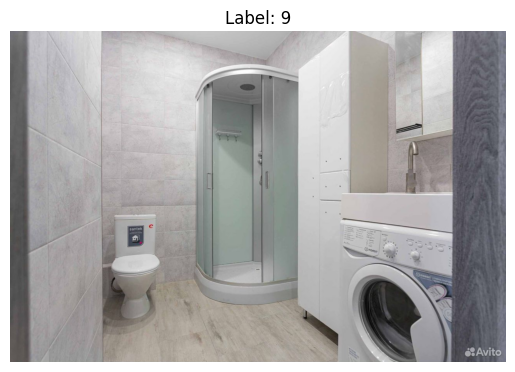

In [ ]:


img, label = train_dataset[0]

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [ ]:
# Преобразования для обучающей выборки (с аугментациями)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Изменяем размер изображения до 224×224 пикселей — стандартный размер для многих CNN
    transforms.RandomHorizontalFlip(p=0.5),  # С вероятностью 50 % зеркально отражаем изображение по горизонтали — аугментация для увеличения разнообразия данных
    transforms.ToTensor(),  # Конвертируем PIL‑изображение в тензор PyTorch и масштабируем значения пикселей в диапазон [0, 1]
    transforms.Normalize(  # Нормализуем значения пикселей по каналам (RGB)
        mean=[0.485, 0.456, 0.406],  # Средние значения для каждого канала (предобученные на ImageNet)
        std=[0.229, 0.224, 0.225]   # Стандартные отклонения для каждого канала (предобученные на ImageNet)
    )
])

# Преобразования для валидационной выборки (без аугментаций)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Изменяем размер изображения до 224×224 пикселей
    transforms.ToTensor(),  # Конвертируем изображение в тензор и масштабируем в диапазон [0, 1]
    transforms.Normalize(  # Нормализуем по тем же параметрам, что и для обучения
        mean=[0.485, 0.456, 0.406],  # Те же средние значения (согласованность с обучением)
        std=[0.229, 0.224, 0.225]   # Те же стандартные отклонения (согласованность с обучением)
    )
])


In [ ]:
# Базовый путь к директории с данными
data_path = '../data/room_type/'

# Путь к CSV‑файлу с исходными данными для обучения
source_df_path = data_path + 'train_df.csv'
# Путь к папке с изображениями для обучения (внутри папки train_images находится подпапка train_images)
images_dir = data_path + 'train_images/train_images'

# Пути для сохранения разделённых данных: обучающей и валидационной выборок
train_split_path = data_path + 'train_split.csv'
val_split_path = data_path + 'val_split.csv'

import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Читаем исходный CSV‑файл с данными в DataFrame
df = pd.read_csv(source_df_path)

# Разделяем данные на обучающую и валидационную выборки
train_df, val_df = train_test_split(
    df,  # Исходный DataFrame с данными
    test_size=0.2,  # Размер валидационной выборки — 20 % от общего объёма
    random_state=42,  # Фиксируем генератор случайных чисел для воспроизводимости результата
    stratify=df["label"]  # Обеспечиваем одинаковое распределение классов в обеих выборках
)

# Сохраняем разделённые данные в отдельные CSV‑файлы без столбца индекса
train_df.to_csv(train_split_path, index=False)
val_df.to_csv(val_split_path, index=False)

# Создаём экземпляры датасета для обучения и валидации
# Используем разделённые CSV‑файлы и соответствующие преобразования изображений
train_dataset = RoomSet(train_split_path, images_dir, transform=train_transform)
val_dataset = RoomSet(val_split_path, images_dir, transform=val_transform)

# Создаём загрузчики данных (DataLoader) для подачи данных в модель
train_loader = DataLoader(
    train_dataset,  # Датасет для обучения
    batch_size=16,  # Размер батча: 16 изображений за итерацию
    shuffle=True,  # Перемешиваем данные на каждой эпохе — улучшает обучение
    drop_last=False  # Не отбрасываем последний неполный батч, если он меньше 16
)
val_loader = DataLoader(
    val_dataset,  # Датасет для валидации
    batch_size=16,  # Размер батча — 16 изображений
    shuffle=False,  # На валидации перемешивание не нужно — оценка будет стабильнее
    drop_last=False  # Аналогично: сохраняем все данные для полной оценки
)


In [10]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:5])

torch.Size([16, 3, 224, 224])
torch.Size([16])
tensor([19, 13,  7,  8, 17])


In [11]:
images, labels = next(iter(val_loader))

print(images.shape)
print(labels.shape)
print(labels[:5])

torch.Size([16, 3, 224, 224])
torch.Size([16])
tensor([ 9, 17,  3, 17,  6])


In [12]:
import timm
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "convnext_tiny.in12k_ft_in1k",
    pretrained=True,
    num_classes=20
).to(device)

import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)


model.train()

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

print("Одна эпоха обучения завершена")

/home/alex/Yandex.Disk/mystuff/MIFI/Hakaton_2_semestr/hakathon_avito_CV2/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Одна эпоха обучения завершена


In [13]:
from sklearn.metrics import f1_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

macro_f1 = f1_score(all_labels, all_preds, average="macro")
print("Validation Macro F1:", macro_f1)

Validation Macro F1: 0.6210831654942658
